In [1]:
!pip install --user matplotlib
!pip install --user pandas
!pip install --user tqdm

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic


In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

from tqdm.notebook import tqdm

In [21]:
result_dir = "/Users/chanb/research/ualberta/hint_rl/data/hint_rl_run"

result_dirs = [
    ("/home/chanb/scratch/hint_rl_results/logs/chanb/openmath-dapo/local_train-hint_rl", 0, 0),
    ("/home/chanb/scratch/hint_rl_results/logs/chanb/openmath-dapo/local_train-hint_rl-continue_from_163", 163, 11),
]

all_rows = []
for (result_dir, pretrained_step, pretrained_epoch) in result_dirs:
    epoch = 1
    epoch_step = 1
    train_step = 1
    rows = []
    main_log = os.path.join(result_dir, "main.log")
    with open(main_log, "r") as f:
        for line in tqdm(f):
            if "INFO: Updated hint percentages:" in line:
                for key_val in line.split("{")[1].split("}")[0].split(","):
                    key, val = key_val.split(":")
                    key = int(key.strip())
                    val = float(val.strip())
                    rows.append({
                        "sample_idx": key,
                        "hint_percentage": str(val)[:3] if val >= 0.1 else str(0.0),
                    })
                    has_added = True
    
            if "StatsLogger INFO: Epoch" in line and "done." in line:
                epoch = int(line.split("Epoch ")[1].split("/")[0]) + pretrained_epoch
                train_step = int(line.split("Train step ")[1].split("/")[0]) + pretrained_step
                epoch_step = int(line.split("Step ")[1].split("/")[0])
    
                rows = [dict(**row, epoch=epoch, train_step=train_step, epoch_step=epoch_step) for row in rows]
                all_rows.extend(rows)
                rows = []

df = pd.DataFrame(all_rows)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [22]:
df

,sample_idx,hint_percentage,epoch,train_step,epoch_step
0,13,1.0,1,1,1
1,58,1.0,1,1,1
2,63,1.0,1,1,1
3,70,1.0,1,1,1
4,71,1.0,1,1,1
...,...,...,...,...,...
1211213,1408,0.7,48,670,3
1211214,1259,0.7,48,670,3
1211215,1495,0.9,48,670,3
1211216,1556,0.9,48,670,3


In [23]:
epochs = np.sort(df.epoch.unique())
sample_idxes = np.sort(df.sample_idx.unique())
hint_percentages = np.sort(df.hint_percentage.unique())

In [24]:
df.epoch_step.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

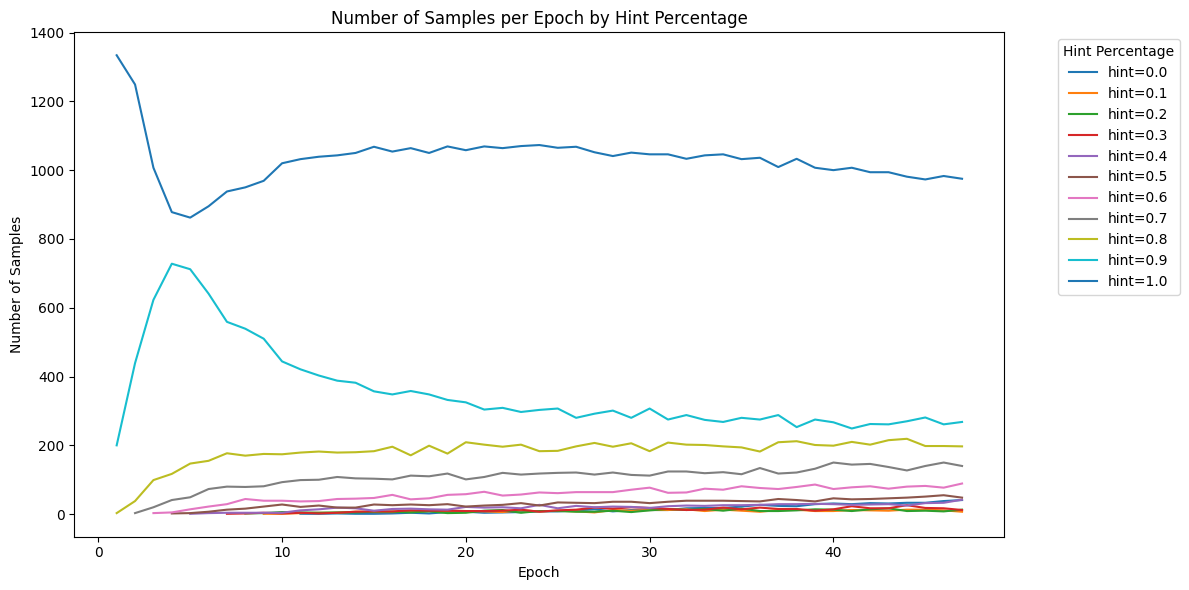

In [25]:
# Group by epoch and hint_percentage, count number of samples
sub_df = df[df.train_step % max(df.epoch_step.unique()) == 0]
grouped = sub_df.groupby(['epoch', 'hint_percentage'])['sample_idx'].count().reset_index()
grouped.columns = ['epoch', 'hint_percentage', 'num_samples']

# Pivot so each hint_percentage becomes a column
pivoted = grouped.pivot(index='epoch', columns='hint_percentage', values='num_samples')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))


for hint_pct in pivoted.columns:
    ax.plot(pivoted.index, pivoted[hint_pct], label=f'hint={hint_pct}')

ax.set_xlabel('Epoch')
ax.set_ylabel('Number of Samples')
ax.set_title('Number of Samples per Epoch by Hint Percentage')
ax.legend(title='Hint Percentage', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [26]:
# Perhaps the same question is being sampled multiple times---need to check.
df[df.epoch == 1].hint_percentage.unique()

<StringArray>
['1.0', '0.9', '0.8']
Length: 3, dtype: str

In [ ]:
# Get the last epoch_step for each epoch
last_step = df[df['epoch_step'] == df.groupby('epoch')['epoch_step'].transform('max')]

# Pivot: rows = sample_idx, columns = epoch, values = hint_percentage
pivoted = last_step.pivot_table(index='sample_idx', columns='epoch', values='hint_percentage')

# Compute diff between consecutive epochs (epoch+1 minus epoch)
epoch_diff = pivoted.diff(axis=1)

# Result: each column is the diff from the previous epoch
# Drop the first epoch column (no previous epoch to diff against)
epoch_diff = epoch_diff.drop(columns=pivoted.columns[0])
epoch_diff